In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ISLP import load_data

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

In [94]:
hitters = load_data("Hitters").dropna()

y = hitters["Salary"]

X = pd.get_dummies(
    hitters.drop(columns="Salary"),
    drop_first=True,
    dtype=float
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=1
)

hitters

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [95]:
ols = LinearRegression()
ols.fit(X_train, y_train)

ols_coef = pd.DataFrame({
    "features": X_train.columns,
    "coefs": ols.coef_
}).sort_values(by="coefs", key=abs, ascending=False)

ols_coef    # some coefficients are suspicious due to collinearity

,features,coefs
17,Division_W,-124.844775
16,League_N,29.003932
18,NewLeague_N,13.518478
1,Hits,7.606262
6,Years,6.983902
5,Walks,5.664732
2,HmRun,-2.920254
3,Runs,-2.260796
0,AtBat,-2.222964
4,RBI,2.188527


In [96]:
y_train_pred = ols.predict(X_train)
y_test_pred = ols.predict(X_test)

print("train RMSE =", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("train R^2 =", r2_score(y_train, y_train_pred))
print("test RMSE =", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("test R^2 =", r2_score(y_test, y_test_pred))

train RMSE = 293.6462803089084
train R^2 = 0.5772501737924396
test RMSE = 353.69968412067516
test R^2 = 0.3733488560057836


In [125]:
ridge = make_pipeline(
    StandardScaler(),
    Ridge(alpha=100)
)
ridge.fit(X_train, y_train)

ridge_coef = pd.DataFrame({
    "features": X_train.columns,
    "coefs": ridge[-1].coef_
}).sort_values(by="coefs", key=abs, ascending=False)

print("train RMSE =", np.sqrt(mean_squared_error(y_train, ridge.predict(X_train))))
print("train R^2 =", r2_score(y_train, ridge.predict(X_train)))
print("test RMSE =", np.sqrt(mean_squared_error(y_test, ridge.predict(X_test))))
print("test R^2 =", r2_score(y_test, ridge.predict(X_test)))

# lower train R^2 but higher test R^2

train RMSE = 325.0478354219965
train R^2 = 0.4820009222209596
test RMSE = 338.55797612693453
test R^2 = 0.4258536706569064


Text(0, 0.5, 'coefficient')

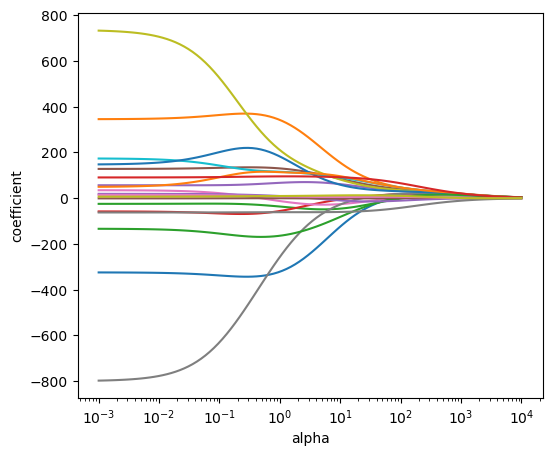

In [152]:
alphas = np.logspace(-3, 4, 100)

ridge_coefs = []

for alpha in alphas:
    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=alpha)
    )
    model.fit(X_train, y_train)
    ridge_coefs.append(model[-1].coef_)

ridge_coefs = np.array(ridge_coefs)
fig, ax = plt.subplots(figsize = (6,5))
ax.plot(alphas, ridge_coefs)
ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("coefficient")

In [153]:
ridge_cv = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=alphas, cv=5)
)
ridge_cv.fit(X_train, y_train)

best_alpha = ridge_cv[-1].alpha_
best_r2 = ridge_cv[-1].best_score_

In [154]:
lasso = make_pipeline(
    StandardScaler(),
    Lasso(alpha=10, max_iter=1000000)
)
lasso.fit(X_train, y_train)

lasso_coef = pd.DataFrame({
    "features": X_train.columns,
    "coefs": lasso[-1].coef_
}).sort_values(by="coefs", key=abs, ascending=False)

print("train RMSE =", np.sqrt(mean_squared_error(y_train, lasso.predict(X_train))))
print("train R^2 =", r2_score(y_train, lasso.predict(X_train)))
print("test RMSE =", np.sqrt(mean_squared_error(y_test, lasso.predict(X_test))))
print("test R^2 =", r2_score(y_test, lasso.predict(X_test)))

train RMSE = 317.799639937771
train R^2 = 0.504844928473358
test RMSE = 340.0284821993444
test R^2 = 0.4208552994753243


Text(0, 0.5, 'coefficient')

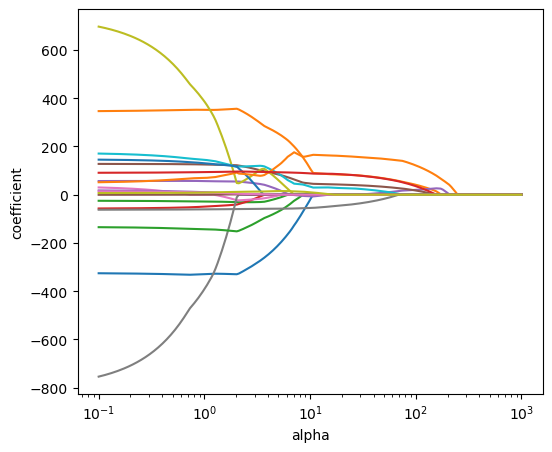

In [163]:
alphas = np.logspace(-1, 3, 200)

lasso_coefs = []

for alpha in alphas:
    model = make_pipeline(
        StandardScaler(),
        Lasso(alpha=alpha, max_iter=1000000)
    )
    model.fit(X_train, y_train)
    lasso_coefs.append(model[-1].coef_)

lasso_coefs = np.array(lasso_coefs)
fig1, ax1 = plt.subplots(figsize = (6,5))
ax1.plot(alphas, lasso_coefs)
ax1.set_xscale("log")
ax1.set_xlabel("alpha")
ax1.set_ylabel("coefficient")

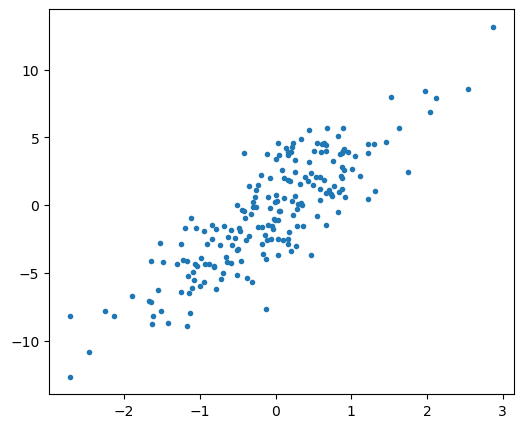

In [250]:
rng = np.random.default_rng(1)

n = 200
x1 = rng.normal(size=n)
x2 = x1 + rng.normal(scale=0.1, size=n)
x3 = rng.normal(size=n)

y = 2 * x1 + 2 * x2 + rng.normal(scale=2, size=n)

X = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "x3": x3
})

fig2, ax2 = plt.subplots(figsize=(6,5))
ax2.plot(x1, y, ".")

In [251]:
ols = LinearRegression()
ols.fit(X, y)
ols.coef_

array([0.71431926, 3.05827317, 0.03579797])

Text(0, 0.5, 'coefficient')

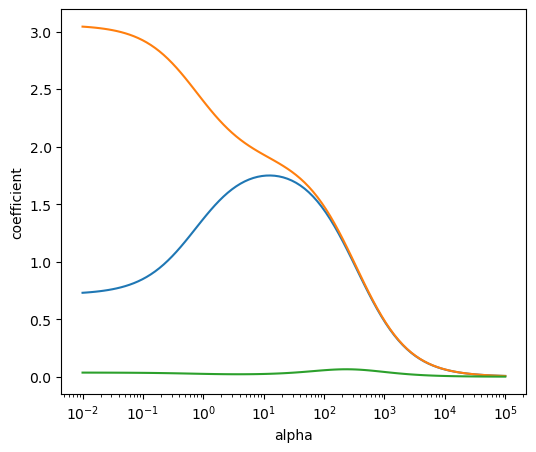

In [252]:
alphas = np.logspace(-2, 5, 100)

ridge_coefs = []

for alpha in alphas:
    model = make_pipeline(
        #StandardScaler(),
        Ridge(alpha=alpha)
    )
    model.fit(X, y)
    ridge_coefs.append(model[-1].coef_)

ridge_coefs = np.array(ridge_coefs)
fig, ax = plt.subplots(figsize = (6,5))
ax.plot(alphas, ridge_coefs)
ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("coefficient")

Text(0, 0.5, 'coefficient')

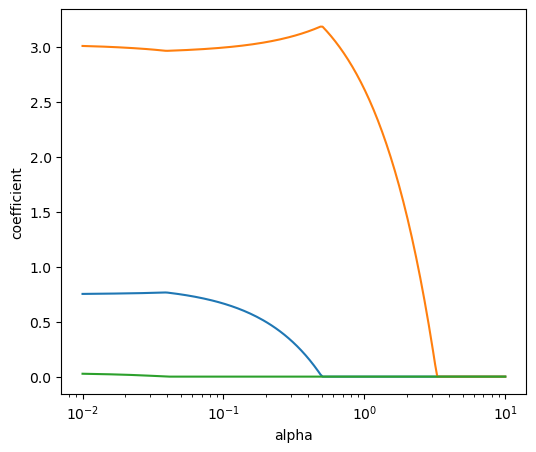

In [253]:
alphas = np.logspace(-2, 1, 200)

lasso_coefs = []

for alpha in alphas:
    model = make_pipeline(
        #StandardScaler(),
        Lasso(alpha=alpha, max_iter=100000)
    )
    model.fit(X, y)
    lasso_coefs.append(model[-1].coef_)

lasso_coefs = np.array(lasso_coefs)
fig1, ax1 = plt.subplots(figsize = (6,5))
ax1.plot(alphas, lasso_coefs)
ax1.set_xscale("log")
ax1.set_xlabel("alpha")
ax1.set_ylabel("coefficient")